In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

/Users/tobiasmanwaring/Documents/UCL/Repos/Other/trTesting/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,RSI,RSI_Strategy,BB_SMA,BB_STD,Upper_Band,Lower_Band,BB_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
32,5147.224121,5153.162495,5098.370752,5147.224121,2160496,68.106485,0.0,4999.964746,105.190238,5105.154984,4894.774508,NaN,NaN,0,NaN,NaN
33,5167.614746,5185.706786,5149.522223,5167.614746,6130800,67.300821,0.0,5012.039551,110.017223,5122.056773,4902.022328,-1.0,-1.0,0,0.003961,0.000000
34,5143.383789,5179.568339,5118.047114,5143.383789,2285344,69.903819,0.0,5024.824878,109.661688,5134.486566,4915.163190,-1.0,-1.0,0,-0.000746,0.000000
35,5134.201172,5152.214439,5116.187904,5134.201172,924160,68.209281,0.0,5035.634814,109.232508,5144.867323,4926.402306,-1.0,-1.0,0,-0.002530,0.000000
36,5177.392090,5181.865685,5143.226620,5177.392090,1295632,69.486121,0.0,5047.691675,110.979959,5158.671634,4936.711716,0.0,0.0,0,0.005861,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7521,2865.135986,2886.133319,2859.461658,2872.635034,4132260,66.968771,0.0,2783.921362,73.973591,2857.894954,2709.947771,-1.0,-1.0,0,-0.443363,0.126337
7522,2866.635742,2901.631295,2838.639300,2879.634091,9204439,64.540535,0.0,2791.170435,74.651207,2865.821642,2716.519227,-1.0,-1.0,0,-0.443072,0.126337
7523,2928.627930,2938.626659,2867.135742,2874.634789,21932776,64.309016,0.0,2800.944189,79.306616,2880.250805,2721.637574,-1.0,-1.0,0,-0.431028,0.126337
7524,2944.000000,2962.500000,2911.400879,2942.000000,23119148,65.950618,0.0,2814.461169,79.508647,2893.969817,2734.952522,-1.0,-1.0,0,-0.428041,0.126337


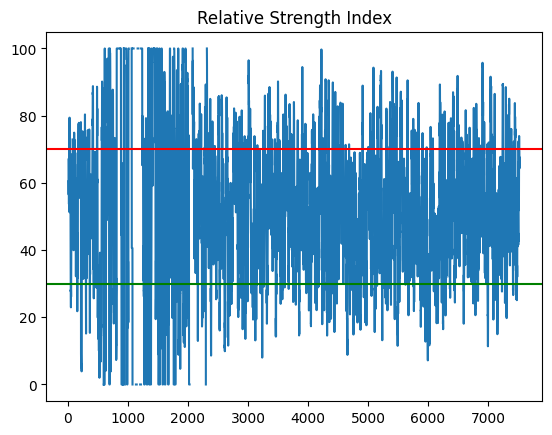

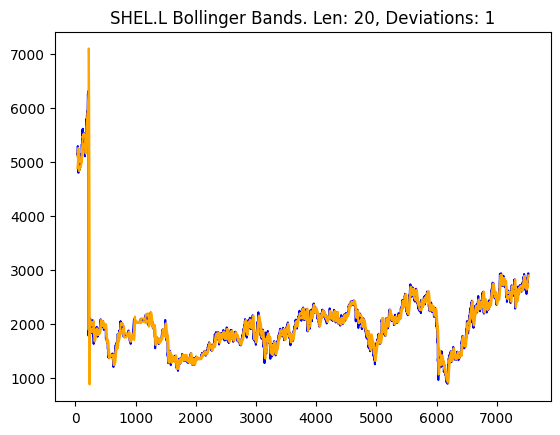

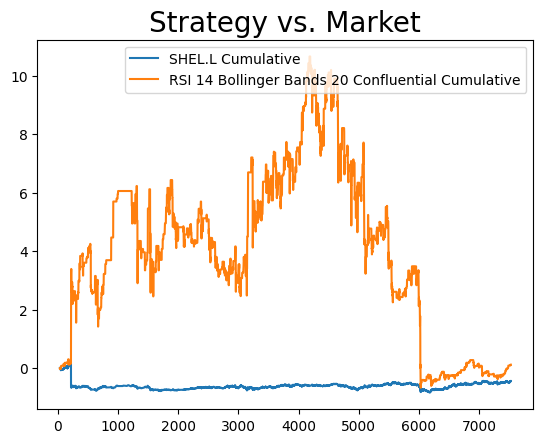

In [2]:
TICKER = 'SHEL.L'
INTERVAL='1d'


if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'


BB_LEN = 20
DEVS = 1
RSI_LENGTH = 14
RSI_OVERBOUGHT = 70
RSI_OVERSOLD = 30
LOOKBACK = 10000


def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    df = yf.download(ticker, interval=interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    df = df.reset_index(drop=True)

    return df.iloc[-lookback:, :]


def add_RSI(df, length=RSI_LENGTH, overbought=RSI_OVERBOUGHT, oversold=RSI_OVERSOLD):
    price_change = df['Close'].diff()
    
    gain = price_change.where(price_change > 0, 0)
    loss = -price_change.where(price_change < 0, 0)

    avg_gain = gain.rolling(window=length).mean()
    avg_loss = loss.rolling(window=length).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    df['RSI'] = rsi

    plt.plot(df['RSI'])
    plt.axhline(overbought, color='red')
    plt.axhline(oversold, color='green')
    plt.title('Relative Strength Index')

    return df.dropna()


def add_RSI_strategy(df, overbought=RSI_OVERBOUGHT, oversold=RSI_OVERSOLD):

    df['RSI_Strategy'] = 0
    df['RSI_Strategy'] = np.where(df['RSI'] > overbought, -1, np.where(df['RSI'] < oversold, 1, 0))
    
    df['RSI_Strategy'] = df['RSI_Strategy'].shift(1)
    return df


def add_BB(df, devs=DEVS, bb_len=BB_LEN):
    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band'] = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band'] = df['BB_SMA'] - (devs * df['BB_STD'])

    df = df.dropna()

    plt.figure()
    plt.plot(df['Close'], color='blue')
    plt.plot(df['Upper_Band'], color='orange')
    plt.plot(df['Lower_Band'], color='orange')

    plt.title(f'{TICKER} Bollinger Bands. Len: {BB_LEN}, Deviations: {DEVS}');

    return df


def add_BB_strategy(df):
    df['BB_Strategy'] = 0
    df['BB_Strategy'] = np.where(df['Close'] > df['Upper_Band'], -1, np.where(df['Close'] < df['Lower_Band'], 1, 0))
    
    df['BB_Strategy'] = df['BB_Strategy'].shift(1)
    
    return df


def add_full_strategy(df):
    df['Full_Strategy'] = df['RSI_Strategy'] + df['BB_Strategy']

    df['Strategy'] = np.where(df['Full_Strategy'] == 2, 3, np.where(df['Full_Strategy'] == -2, -3, 0))

    return df


def test_strategy(df):
    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', f'RSI {RSI_LENGTH} Bollinger Bands {BB_LEN} Confluential Cumulative'])
    plt.title('Strategy vs. Market', size='20')

    return df


def main():
    df = get_data()
    df = add_RSI(df)
    df = add_RSI_strategy(df)
    df = add_BB(df)
    df = add_BB_strategy(df)
    df = add_full_strategy(df)
    df = test_strategy(df)

    return df


df = main()

df